# Olympic Medal Prediction  
## Final report Notebook — Sections 3, 4, 5, and 6

- **3. Data Overview**
- **4. Data Preparation (ETL + Validation + Leakage Prevention)**
- **5. Exploratory Data Analysis (EDA Insights)**
- **6. Predictive Modeling**

# Setup: Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

df_raw = pd.read_csv("Analysing the Olympics for last 120 yrs.(2).csv")

print("Raw dataset shape:", df_raw.shape)
display(df_raw.head())

Raw dataset shape: (271116, 15)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


# 3. Data Overview

This section proves that we understand the dataset, its structure, its grain, its target variable, and early limitations.


## 3.1 Source and Permissions

**Dataset source:** Kaggle, *120 years of Olympic history: athletes and results*  
**Dataset link:** https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results

The dataset is publicly available on Kaggle and is used here for academic analysis.  
In the final Word report, include the Kaggle link and any visible license or usage note from the dataset page.


## 3.2 Unit of Analysis (Grain)

One row represents **one athlete participating in one Olympic event in one Olympic Games/year**.

This is important because the same athlete can appear multiple times across different events and Olympic years.


In [2]:
total_rows = len(df_raw)
unique_ids = df_raw["ID"].nunique()
duplicate_rows = df_raw.duplicated().sum()

key_uniqueness_summary = pd.DataFrame({
    "Check": [
        "Total raw rows",
        "Unique athlete IDs",
        "Exact duplicate rows",
        "Is ID unique?",
        "Correct dataset grain"
    ],
    "Result": [
        f"{total_rows:,}",
        f"{unique_ids:,}",
        f"{duplicate_rows:,}",
        "No" if total_rows != unique_ids else "Yes",
        "One athlete-event participation record"
    ]
})

key_uniqueness_summary

,Check,Result
0,Total raw rows,"271,116"
1,Unique athlete IDs,"135,571"
2,Exact duplicate rows,"1,385"
3,Is ID unique?,No
4,Correct dataset grain,One athlete-event participation record


## 3.3 Data Structure (Flat Table)

This project uses one CSV file, so the dataset is treated as a **flat analytical table**.

A flat table means all main information is already stored in one table, and no joins between multiple tables are required.


In [3]:
print("Raw rows:", len(df_raw))
print("Raw columns:", df_raw.shape[1])
print("Column names:")
print(list(df_raw.columns))

df_raw.info()

Raw rows: 271116
Raw columns: 15
Column names:
['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


## 3.4 Key Fields and Uniqueness

The `ID` field represents athlete identifiers, but it is not unique because athletes can appear in multiple events and years.

Therefore, `ID` alone cannot be used as the unique row key. The correct analytical grain is one athlete-event participation record.


In [4]:
key_fields_uniqueness_table = pd.DataFrame({
    "Field / Check": [
        "ID",
        "Name",
        "Medal",
        "Total raw rows",
        "Unique athlete IDs",
        "Exact duplicate rows",
        "Rows after duplicate removal"
    ],
    "Result": [
        "Not unique; athletes can appear in multiple events/years",
        "Excluded from modeling because it can cause memorization",
        "Used to create the target variable, then excluded from modeling",
        f"{len(df_raw):,}",
        f"{df_raw['ID'].nunique():,}",
        f"{df_raw.duplicated().sum():,}",
        f"{len(df_raw.drop_duplicates()):,}"
    ]
})

key_fields_uniqueness_table

,Field / Check,Result
0,ID,Not unique; athletes can appear in multiple ev...
1,Name,Excluded from modeling because it can cause me...
2,Medal,"Used to create the target variable, then exclu..."
3,Total raw rows,"271,116"
4,Unique athlete IDs,"135,571"
5,Exact duplicate rows,"1,385"
6,Rows after duplicate removal,"269,731"


## 3.5 Time Period and Scope

This section documents the time range and scope of the Olympic dataset.


In [5]:
df_clean = df_raw.drop_duplicates().copy()
df_clean["Medal_Won"] = df_clean["Medal"].notna().astype(int)

scope_summary = pd.DataFrame({
    "Item": [
        "Minimum Olympic year",
        "Maximum Olympic year",
        "Number of sports",
        "Number of events",
        "Number of NOCs",
        "Number of teams",
        "Number of cities"
    ],
    "Result": [
        df_clean["Year"].min(),
        df_clean["Year"].max(),
        df_clean["Sport"].nunique(),
        df_clean["Event"].nunique(),
        df_clean["NOC"].nunique(),
        df_clean["Team"].nunique(),
        df_clean["City"].nunique()
    ]
})

scope_summary

,Item,Result
0,Minimum Olympic year,1896
1,Maximum Olympic year,2016
2,Number of sports,66
3,Number of events,765
4,Number of NOCs,230
5,Number of teams,1184
6,Number of cities,42


## 3.6 Target Variable Definition

The target variable is `Medal_Won`.

- `Medal_Won = 1` means the athlete won Gold, Silver, or Bronze.
- `Medal_Won = 0` means the athlete did not win a medal.

This creates a binary classification task.


In [6]:
class_balance = pd.DataFrame({
    "Class": ["No Medal", "Medal"],
    "Target_Value": [0, 1],
    "Count": df_clean["Medal_Won"].value_counts().sort_index().values,
    "Percent": (df_clean["Medal_Won"].value_counts(normalize=True).sort_index().values * 100).round(2)
})

class_balance

,Class,Target_Value,Count,Percent
0,No Medal,0,229959,85.25
1,Medal,1,39772,14.75


## 3.7 Dataset Fact Sheet

**Table 3.2: Dataset Fact Sheet**

This table summarizes the key characteristics of the dataset used for analysis.


In [7]:
df_clean["Height_m"] = df_clean["Height"] / 100
df_clean["BMI"] = df_clean["Weight"] / (df_clean["Height_m"] ** 2)
df_clean["BMI"] = df_clean["BMI"].replace([np.inf, -np.inf], np.nan)

fact_sheet = pd.DataFrame({
    "Item": [
        "Raw dataset size",
        "Duplicate rows removed",
        "Cleaned dataset size",
        "Final unit of analysis",
        "Data structure",
        "Time period",
        "Target variable",
        "Class balance",
        "Key variables",
        "Leakage fields excluded"
    ],
    "Result": [
        f"{df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns",
        f"{duplicate_rows:,}",
        f"{df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns",
        "One athlete participating in one event in one Olympic Games/year",
        "Single CSV file treated as a flat analytical table",
        f"{df_clean['Year'].min()}–{df_clean['Year'].max()}",
        "Medal_Won (1 = medal, 0 = no medal)",
        f"{class_balance.loc[0, 'Percent']}% no medal; {class_balance.loc[1, 'Percent']}% medal",
        "Sex, Age, Height, Weight, BMI, Year, Season, Sport, Event",
        "ID, Name, Medal"
    ]
})

fact_sheet

,Item,Result
0,Raw dataset size,"271,116 rows × 15 columns"
1,Duplicate rows removed,"1,385"
2,Cleaned dataset size,"269,731 rows × 18 columns"
3,Final unit of analysis,One athlete participating in one event in one ...
4,Data structure,Single CSV file treated as a flat analytical t...
5,Time period,1896–2016
6,Target variable,"Medal_Won (1 = medal, 0 = no medal)"
7,Class balance,85.25% no medal; 14.75% medal
8,Key variables,"Sex, Age, Height, Weight, BMI, Year, Season, S..."
9,Leakage fields excluded,"ID, Name, Medal"


## 3.8 Data Dictionary Summary

This table gives a summary of key variables.  
The full data dictionary can be placed in the Appendix.


In [8]:
data_dictionary_summary = pd.DataFrame({
    "Field": [
        "ID", "Name", "Sex", "Age", "Height", "Weight",
        "Team", "NOC", "Games", "Year", "Season",
        "City", "Sport", "Event", "Medal", "Medal_Won", "BMI"
    ],
    "Type": [
        "Identifier", "Text", "Categorical", "Numeric", "Numeric", "Numeric",
        "Categorical", "Categorical", "Categorical", "Numeric", "Categorical",
        "Categorical", "Categorical", "Categorical", "Categorical", "Binary", "Numeric"
    ],
    "Meaning": [
        "Athlete ID",
        "Athlete name",
        "Gender (M/F)",
        "Age at Olympic Games",
        "Height in centimeters",
        "Weight in kilograms",
        "Team name",
        "Country code",
        "Games label",
        "Olympic year",
        "Summer or Winter",
        "Host city",
        "Sport category",
        "Specific event",
        "Medal type or missing",
        "1 = medal, 0 = no medal",
        "Body Mass Index"
    ],
    "Role": [
        "Removed (leakage/memorization risk)",
        "Removed (high cardinality/memorization risk)",
        "Predictor",
        "Predictor (missing values)",
        "Predictor (missing values)",
        "Predictor (missing values)",
        "Potential predictor (high cardinality)",
        "Potential predictor",
        "Context field",
        "Predictor",
        "Predictor",
        "Context field",
        "Predictor",
        "Predictor (high cardinality)",
        "Used to create target, then removed",
        "Target variable",
        "Engineered predictor"
    ]
})

data_dictionary_summary

,Field,Type,Meaning,Role
0,ID,Identifier,Athlete ID,Removed (leakage/memorization risk)
1,Name,Text,Athlete name,Removed (high cardinality/memorization risk)
2,Sex,Categorical,Gender (M/F),Predictor
3,Age,Numeric,Age at Olympic Games,Predictor (missing values)
4,Height,Numeric,Height in centimeters,Predictor (missing values)
5,Weight,Numeric,Weight in kilograms,Predictor (missing values)
6,Team,Categorical,Team name,Potential predictor (high cardinality)
7,NOC,Categorical,Country code,Potential predictor
8,Games,Categorical,Games label,Context field
9,Year,Numeric,Olympic year,Predictor


## 3.9 Early Limitations

The early review identifies several important limitations:

1. Missing values exist in Age, Height, Weight, and BMI.
2. The target variable is highly imbalanced.
3. Athlete IDs are repeated because athletes can participate in multiple events and years.
4. Some categorical fields such as Event and Team have high cardinality.
5. The dataset is historical and only covers Olympics through 2016.
6. Some countries, sports, or time periods may be overrepresented, creating possible bias.
7. Athlete measurements may not be consistently recorded across all years.


In [9]:
missing_summary = (
    df_clean.isna()
    .sum()
    .reset_index(name="Missing_Count")
    .rename(columns={"index": "Column"})
)

missing_summary["Missing_Percent"] = (
    missing_summary["Missing_Count"] / len(df_clean) * 100
).round(2)

missing_summary = missing_summary.sort_values("Missing_Count", ascending=False)

missing_summary.head(12)

,Column,Missing_Count,Missing_Percent
14,Medal,229959,85.25
17,BMI,62891,23.32
5,Weight,61527,22.81
16,Height_m,58814,21.80
4,Height,58814,21.80
3,Age,9315,3.45
11,City,0,0.00
15,Medal_Won,0,0.00
13,Event,0,0.00
12,Sport,0,0.00


# 4. Data Preparation (ETL + Validation + Leakage Prevention)

This section documents how the raw dataset becomes a cleaned and modeling-ready analytic table.


## 4.1 Analytic Table Build (ETL)

The ETL process follows four main stages: raw data, cleaned data, feature engineering, and final analytic table.


### 4.1.1 Raw Data

The raw dataset was loaded from the original CSV file.


In [10]:
raw_stage = pd.DataFrame({
    "Stage": ["Raw data"],
    "Rows": [len(df_raw)],
    "Columns": [df_raw.shape[1]],
    "Description": ["Original CSV loaded into pandas"]
})

raw_stage

,Stage,Rows,Columns,Description
0,Raw data,271116,15,Original CSV loaded into pandas


### 4.1.2 Cleaned Data

Exact duplicate rows were removed to improve data quality.


In [11]:
cleaned_stage = pd.DataFrame({
    "Stage": ["Cleaned data"],
    "Rows": [len(df_clean)],
    "Columns": [df_clean.shape[1]],
    "Description": [f"Removed {duplicate_rows:,} duplicate rows and created Medal_Won"]
})

cleaned_stage

,Stage,Rows,Columns,Description
0,Cleaned data,269731,18,"Removed 1,385 duplicate rows and created Medal..."


### 4.1.3 Feature Engineering

BMI was created from height and weight to better represent body composition.


In [12]:
bmi_summary = df_clean[["BMI"]].describe().T.round(2)
bmi_summary

,count,mean,std,min,25%,50%,75%,max
BMI,206840.0,22.78,2.91,8.36,20.96,22.53,24.21,63.9


### 4.1.4 Final Analytic Table

Leakage fields are removed before modeling:

- `ID`: can memorize athletes
- `Name`: can memorize athletes
- `Medal`: directly reveals the target outcome


In [13]:
target = "Medal_Won"

model_features = [
    "Sex", "Age", "Height", "Weight", "BMI",
    "Year", "Season", "Sport", "Event"
]

df_final = df_clean[model_features + [target]].copy()

print("Final analytic table shape:", df_final.shape)
display(df_final.head())

Final analytic table shape: (269731, 10)


,Sex,Age,Height,Weight,BMI,Year,Season,Sport,Event,Medal_Won
0,M,24.0,180.0,80.0,24.691358,1992,Summer,Basketball,Basketball Men's Basketball,0
1,M,23.0,170.0,60.0,20.761246,2012,Summer,Judo,Judo Men's Extra-Lightweight,0
2,M,24.0,NaN,NaN,NaN,1920,Summer,Football,Football Men's Football,0
3,M,34.0,NaN,NaN,NaN,1900,Summer,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,1
4,F,21.0,185.0,82.0,23.959094,1988,Winter,Speed Skating,Speed Skating Women's 500 metres,0


## 4.2 Validation Checks

This section provides evidence that the analytic table is trustworthy.


### 4.2.1 Row Count Check

In [14]:
row_count_check = pd.DataFrame({
    "Step": ["Raw data", "After duplicate removal", "Final analytic table"],
    "Rows": [len(df_raw), len(df_clean), len(df_final)],
    "Columns": [df_raw.shape[1], df_clean.shape[1], df_final.shape[1]]
})

row_count_check

,Step,Rows,Columns
0,Raw data,271116,15
1,After duplicate removal,269731,18
2,Final analytic table,269731,10


### 4.2.2 Duplicate Check

In [15]:
duplicate_check = pd.DataFrame({
    "Dataset": ["Raw data", "Cleaned data"],
    "Duplicate_Rows": [df_raw.duplicated().sum(), df_clean.duplicated().sum()]
})

duplicate_check

,Dataset,Duplicate_Rows
0,Raw data,1385
1,Cleaned data,0


### 4.2.3 Missing Values Check

In [16]:
final_missing_summary = (
    df_final.isna()
    .sum()
    .reset_index(name="Missing_Count")
    .rename(columns={"index": "Column"})
)

final_missing_summary["Missing_Percent"] = (
    final_missing_summary["Missing_Count"] / len(df_final) * 100
).round(2)

final_missing_summary = final_missing_summary.sort_values("Missing_Count", ascending=False)

final_missing_summary

,Column,Missing_Count,Missing_Percent
4,BMI,62891,23.32
3,Weight,61527,22.81
2,Height,58814,21.80
1,Age,9315,3.45
0,Sex,0,0.00
5,Year,0,0.00
6,Season,0,0.00
7,Sport,0,0.00
8,Event,0,0.00
9,Medal_Won,0,0.00


### 4.2.4 Range Check

In [17]:
numeric_range_check = df_clean[["Age", "Height", "Weight", "BMI", "Year"]].describe().T.round(2)
numeric_range_check

,count,mean,std,min,25%,50%,75%,max
Age,260416.0,25.45,6.16,10.00,21.00,24.00,28.00,97.0
Height,210917.0,175.34,10.52,127.00,168.00,175.00,183.00,226.0
Weight,208204.0,70.70,14.35,25.00,60.00,70.00,79.00,214.0
BMI,206840.0,22.78,2.91,8.36,20.96,22.53,24.21,63.9
Year,269731.0,1978.62,29.75,1896.00,1960.00,1988.00,2002.00,2016.0


### 4.2.5 Cardinality Check

In [18]:
cardinality_summary = (
    df_clean.select_dtypes(include="object")
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "Column", 0: "Unique_Values"})
)

cardinality_summary

,Column,Unique_Values
0,Name,134732
1,Team,1184
2,Event,765
3,NOC,230
4,Sport,66
5,Games,51
6,City,42
7,Medal,3
8,Sex,2
9,Season,2


## 4.3 Cleaning and Transformations

This section documents preparation decisions and the reasoning behind them.


### 4.3.1 Missing Value Strategy

Numeric variables use median imputation inside the preprocessing pipeline.  
Median is chosen because it is robust to outliers and preserves rows.

Categorical variables use most-frequent imputation inside the pipeline.


### 4.3.2 Outliers Handling

Outliers were reviewed using numeric summary statistics.  
Values were not removed because they fall within realistic athlete ranges, and removing them could remove valid extreme athlete records.


### 4.3.3 Encoding

Categorical variables such as Sex, Season, Sport, and Event are encoded using one-hot encoding so they can be used in machine learning models.


### 4.3.4 Scaling

Numeric variables are scaled using StandardScaler.  
Scaling keeps variables such as Age, Height, Weight, BMI, and Year on a comparable scale.


### 4.3.5 Feature Engineering

BMI was created from Height and Weight because it combines two related physical variables into one body-composition feature.


## 4.4 Leakage Prevention and Evaluation Setup

The train/test split is performed before preprocessing.  
All imputation, scaling, and encoding are fit only on the training data.

This prevents information from the test set from leaking into model training.


In [19]:
X = df_final[model_features]
y = df_final[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Rows": [len(X_train), len(X_test)],
    "No_Medal_Percent": [
        (y_train.value_counts(normalize=True).sort_index().loc[0] * 100).round(2),
        (y_test.value_counts(normalize=True).sort_index().loc[0] * 100).round(2)
    ],
    "Medal_Percent": [
        (y_train.value_counts(normalize=True).sort_index().loc[1] * 100).round(2),
        (y_test.value_counts(normalize=True).sort_index().loc[1] * 100).round(2)
    ]
})

split_summary

,Dataset,Rows,No_Medal_Percent,Medal_Percent
0,Training,215784,85.26,14.74
1,Testing,53947,85.25,14.75


In [20]:
numeric_features = ["Age", "Height", "Weight", "BMI", "Year"]
categorical_features = ["Sex", "Season", "Sport", "Event"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 4.5 Final Dataset Summary

**Table 4.3: Final Dataset Shape & Missingness**


In [21]:
final_dataset_summary = pd.DataFrame({
    "Item": [
        "Final analytic table rows",
        "Final analytic table columns",
        "Training rows",
        "Testing rows",
        "Target",
        "Evaluation method"
    ],
    "Result": [
        f"{df_final.shape[0]:,}",
        f"{df_final.shape[1]}",
        f"{X_train.shape[0]:,}",
        f"{X_test.shape[0]:,}",
        "Medal_Won",
        "80/20 stratified train/test split"
    ]
})

final_dataset_summary

,Item,Result
0,Final analytic table rows,"269,731"
1,Final analytic table columns,10
2,Training rows,"215,784"
3,Testing rows,"53,947"
4,Target,Medal_Won
5,Evaluation method,80/20 stratified train/test split


## 4.6 Data Preparation Summary Table

**Table 4.2: Data Preparation Summary Table**


In [22]:
data_preparation_summary = pd.DataFrame({
    "Issue": [
        "Duplicate records",
        "Target variable needed",
        "Medal field creates leakage",
        "ID and Name memorization risk",
        "Missing numeric values",
        "Missing categorical values",
        "Outliers/extreme numeric values",
        "Feature engineering needed",
        "Categorical variables",
        "High-cardinality categories",
        "Class imbalance",
        "Preprocessing leakage risk"
    ],
    "Decision": [
        "Removed exact duplicates",
        "Created Medal_Won from Medal",
        "Removed Medal from predictors",
        "Removed ID and Name from predictors",
        "Use median imputation inside pipeline",
        "Use most-frequent imputation inside pipeline",
        "Reviewed ranges; kept values",
        "Created BMI from Height and Weight",
        "Use one-hot encoding",
        "Use handle_unknown='ignore'",
        "Use stratified train/test split",
        "Split before preprocessing"
    ],
    "Justification": [
        "Prevents repeated records from biasing analysis/modeling",
        "Converts medal outcome into binary classification target",
        "Medal directly reveals the outcome",
        "Prevents model from memorizing athlete identity",
        "Median is robust to outliers and preserves rows",
        "Maintains consistency for categorical inputs",
        "Values fall within realistic athlete ranges; removing may delete valid athletes",
        "Combines height and weight into one body-composition feature",
        "Machine learning models require numeric input",
        "Prevents errors when test data contains unseen categories",
        "Preserves class distribution across train/test sets",
        "Prevents test-set information from influencing training"
    ]
})

data_preparation_summary

,Issue,Decision,Justification
0,Duplicate records,Removed exact duplicates,Prevents repeated records from biasing analysi...
1,Target variable needed,Created Medal_Won from Medal,Converts medal outcome into binary classificat...
2,Medal field creates leakage,Removed Medal from predictors,Medal directly reveals the outcome
3,ID and Name memorization risk,Removed ID and Name from predictors,Prevents model from memorizing athlete identity
4,Missing numeric values,Use median imputation inside pipeline,Median is robust to outliers and preserves rows
5,Missing categorical values,Use most-frequent imputation inside pipeline,Maintains consistency for categorical inputs
6,Outliers/extreme numeric values,Reviewed ranges; kept values,Values fall within realistic athlete ranges; r...
7,Feature engineering needed,Created BMI from Height and Weight,Combines height and weight into one body-compo...
8,Categorical variables,Use one-hot encoding,Machine learning models require numeric input
9,High-cardinality categories,Use handle_unknown='ignore',Prevents errors when test data contains unseen...


## 4.7 Save Final Analytic Table

This creates the cleaned analytic table file required by the professor.


In [23]:
df_final.to_csv("analytic_table.csv", index=False)

print("Saved analytic_table.csv")
print("Final analytic table shape:", df_final.shape)

Saved analytic_table.csv
Final analytic table shape: (269731, 10)


# 5. Exploratory Data Analysis (EDA Insights)

This section provides business-facing insights supported by charts and tables.


## 5.1 Descriptive Summary

**Table 5.1: Descriptive Statistics**


In [24]:
numeric_summary = df_clean[["Age", "Height", "Weight", "BMI", "Year"]].describe().T
numeric_summary["median"] = df_clean[["Age", "Height", "Weight", "BMI", "Year"]].median()
numeric_summary = numeric_summary[["count", "mean", "median", "std", "min", "max"]].round(2)

numeric_summary

,count,mean,median,std,min,max
Age,260416.0,25.45,24.00,6.16,10.00,97.0
Height,210917.0,175.34,175.00,10.52,127.00,226.0
Weight,208204.0,70.70,70.00,14.35,25.00,214.0
BMI,206840.0,22.78,22.53,2.91,8.36,63.9
Year,269731.0,1978.62,1988.00,29.75,1896.00,2016.0


## 5.2 Target Distribution

**Figure 5.1: Medal vs No Medal Distribution**


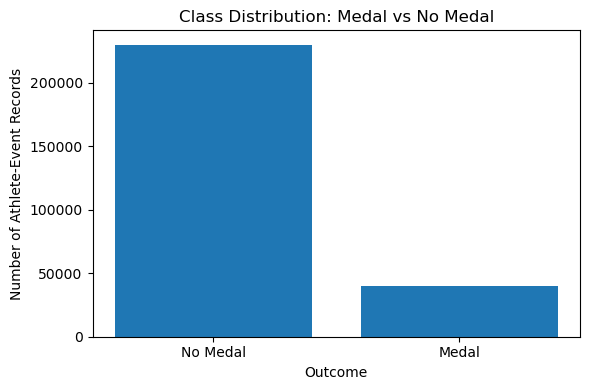

,Class,Target_Value,Count,Percent
0,No Medal,0,229959,85.25
1,Medal,1,39772,14.75


In [25]:
plt.figure(figsize=(6, 4))
plt.bar(class_balance["Class"], class_balance["Count"])
plt.title("Class Distribution: Medal vs No Medal")
plt.xlabel("Outcome")
plt.ylabel("Number of Athlete-Event Records")
plt.tight_layout()
plt.show()

class_balance

**Business insight 1:**  
Medal outcomes are rare. Only about 15% of athlete-event records result in medals, so model evaluation should focus on precision, recall, and F1-score rather than accuracy alone.


## 5.3 Feature Insights

This section compares key features across medal and non-medal outcomes.


### Figure 5.2: Age Distribution by Medal Outcome

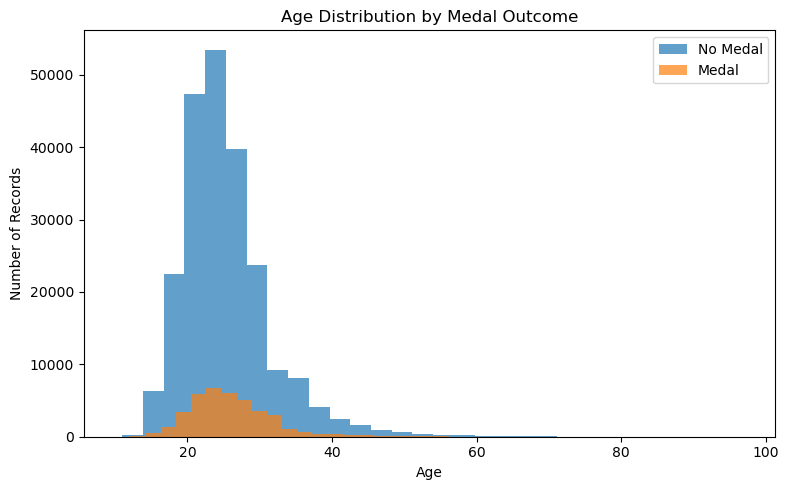

,count,mean,median,std,min,max
No Medal,221372,25.37,24.0,6.20,11.0,97.0
Medal,39044,25.92,25.0,5.91,10.0,73.0


In [26]:
age_data_no_medal = df_clean.loc[df_clean["Medal_Won"] == 0, "Age"].dropna()
age_data_medal = df_clean.loc[df_clean["Medal_Won"] == 1, "Age"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(age_data_no_medal, bins=30, alpha=0.7, label="No Medal")
plt.hist(age_data_medal, bins=30, alpha=0.7, label="Medal")
plt.title("Age Distribution by Medal Outcome")
plt.xlabel("Age")
plt.ylabel("Number of Records")
plt.legend()
plt.tight_layout()
plt.show()

age_by_outcome = (
    df_clean.groupby("Medal_Won")["Age"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

age_by_outcome.index = ["No Medal", "Medal"]
age_by_outcome

**Business insight 2:**  
Age shows some signal, but medal and non-medal distributions overlap heavily. Age alone is not enough to separate medal winners from non-winners.


### Figure 5.3: BMI Distribution by Medal Outcome

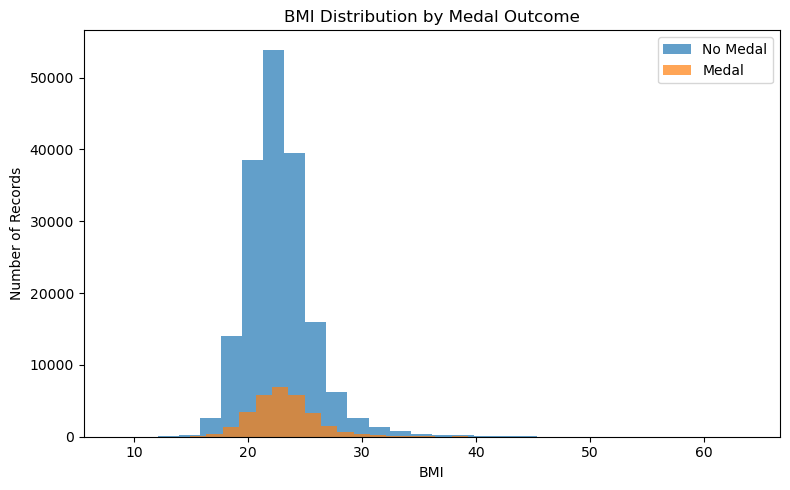

,count,mean,median,std,min,max
No Medal,176644,22.72,22.48,2.90,8.36,63.9
Medal,30196,23.16,22.93,2.96,13.49,56.5


In [27]:
bmi_data_no_medal = df_clean.loc[df_clean["Medal_Won"] == 0, "BMI"].dropna()
bmi_data_medal = df_clean.loc[df_clean["Medal_Won"] == 1, "BMI"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(bmi_data_no_medal, bins=30, alpha=0.7, label="No Medal")
plt.hist(bmi_data_medal, bins=30, alpha=0.7, label="Medal")
plt.title("BMI Distribution by Medal Outcome")
plt.xlabel("BMI")
plt.ylabel("Number of Records")
plt.legend()
plt.tight_layout()
plt.show()

bmi_by_outcome = (
    df_clean.groupby("Medal_Won")["BMI"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

bmi_by_outcome.index = ["No Medal", "Medal"]
bmi_by_outcome

**Business insight 3:**  
BMI may add small predictive value, but there is strong overlap between medal and non-medal records. It should be combined with other variables rather than used alone.


### Figure 5.4: Medal Rate by Sex

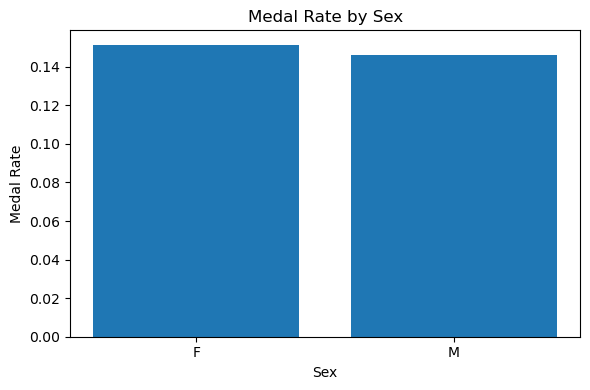

,Sex,Medal_Rate_Percent
0,F,15.13
1,M,14.60


In [28]:
sex_medal_rate = (
    df_clean.groupby("Sex")["Medal_Won"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 4))
plt.bar(sex_medal_rate.index, sex_medal_rate.values)
plt.title("Medal Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Medal Rate")
plt.tight_layout()
plt.show()

(sex_medal_rate * 100).round(2).reset_index(name="Medal_Rate_Percent")

**Business insight 4:**  
Medal rates by sex are relatively close, so sex should not be interpreted alone. It may still help when combined with sport, event, and season.


## 5.4 Segment Analysis

This section compares medal rates across Olympic season, sport, and NOC.


### Figure 5.5: Medal Rate by Season

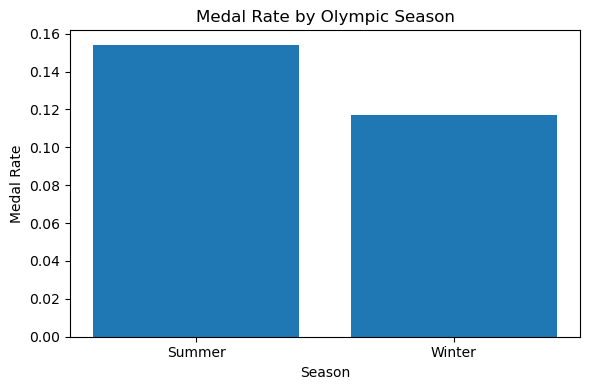

,Season,Medal_Rate_Percent
0,Summer,15.41
1,Winter,11.73


In [29]:
season_medal_rate = (
    df_clean.groupby("Season")["Medal_Won"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 4))
plt.bar(season_medal_rate.index, season_medal_rate.values)
plt.title("Medal Rate by Olympic Season")
plt.xlabel("Season")
plt.ylabel("Medal Rate")
plt.tight_layout()
plt.show()

(season_medal_rate * 100).round(2).reset_index(name="Medal_Rate_Percent")

**Business insight 5:**  
Medal rates differ by Olympic season, which suggests that competition structure and event mix may influence medal probability.


### Figure 5.6: Medal Rate by Sport

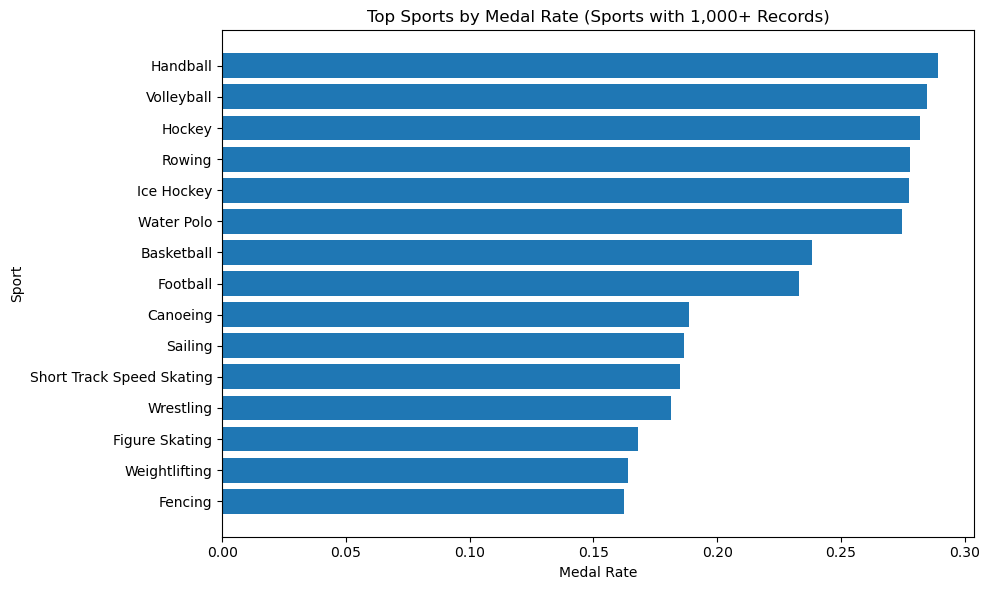

,Sport,Records,Medal_Rate_Percent
28,Handball,3665,28.92
62,Volleyball,3404,28.47
29,Hockey,5417,28.21
43,Rowing,10595,27.80
30,Ice Hockey,5516,27.74
63,Water Polo,3846,27.48
8,Basketball,4536,23.81
24,Football,6745,23.29
14,Canoeing,6171,18.88
46,Sailing,6549,18.64


In [30]:
sport_summary = (
    df_clean.groupby("Sport")
    .agg(
        Records=("Medal_Won", "size"),
        Medal_Rate=("Medal_Won", "mean")
    )
    .reset_index()
)

sport_summary_filtered = sport_summary[sport_summary["Records"] >= 1000].copy()
top_sports_by_rate = sport_summary_filtered.sort_values("Medal_Rate", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_sports_by_rate["Sport"], top_sports_by_rate["Medal_Rate"])
plt.title("Top Sports by Medal Rate (Sports with 1,000+ Records)")
plt.xlabel("Medal Rate")
plt.ylabel("Sport")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_sports_by_rate["Medal_Rate_Percent"] = (top_sports_by_rate["Medal_Rate"] * 100).round(2)
top_sports_by_rate[["Sport", "Records", "Medal_Rate_Percent"]]

**Business insight 6:**  
Medal rates vary meaningfully across sports. Sport context is important, but medal rates should be interpreted with record counts to avoid misleading conclusions from small samples.


### Figure 5.7: Medal Rate by NOC

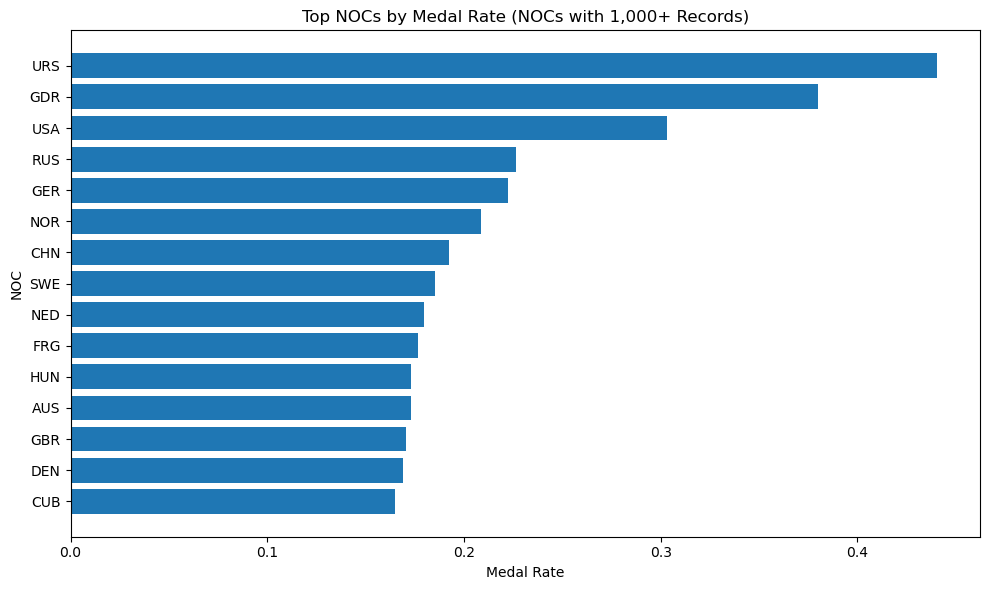

,NOC,Records,Medal_Rate_Percent
214,URS,5685,44.03
76,GDR,2645,38.00
216,USA,18604,30.30
171,RUS,5143,22.65
79,GER,9734,22.24
150,NOR,4954,20.85
41,CHN,5141,19.24
193,SWE,8291,18.53
145,NED,5781,17.99
70,FRG,3315,17.68


In [31]:
noc_summary = (
    df_clean.groupby("NOC")
    .agg(
        Records=("Medal_Won", "size"),
        Medal_Rate=("Medal_Won", "mean")
    )
    .reset_index()
)

noc_summary_filtered = noc_summary[noc_summary["Records"] >= 1000].copy()
top_noc_by_rate = noc_summary_filtered.sort_values("Medal_Rate", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_noc_by_rate["NOC"], top_noc_by_rate["Medal_Rate"])
plt.title("Top NOCs by Medal Rate (NOCs with 1,000+ Records)")
plt.xlabel("Medal Rate")
plt.ylabel("NOC")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_noc_by_rate["Medal_Rate_Percent"] = (top_noc_by_rate["Medal_Rate"] * 100).round(2)
top_noc_by_rate[["NOC", "Records", "Medal_Rate_Percent"]]

**Business insight:**  
Medal rates differ across NOCs, suggesting that national context and historical investment patterns may influence medal outcomes. This should be interpreted carefully because historical representation may create bias.


## 5.5 Key Business Insights

The EDA results show:

1. Medal outcomes are rare and imbalanced.
2. Medal rates differ by season, sport, and NOC.
3. Sex differences exist but should not be overinterpreted alone.
4. Age and BMI show some signal but overlap heavily between outcomes.
5. Sport and NOC context should be interpreted with sample sizes.
6. Missingness and high-cardinality variables create practical modeling challenges.

These findings support using multiple variables together in the modeling stage.


---  
# Transition to Section 6

Sections 3–5 created the cleaned dataset, final analytic table, EDA outputs, and preprocessing setup.  
Section 6 now uses the same cleaned data to build and evaluate predictive models.


In [32]:
# Additional modeling libraries for Section 6
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)


In [33]:
# Prepare modeling dataset for Section 6
# Reuse cleaned dataset created in Sections 3–5
df = df_clean.copy()

target = "Medal_Won"

features_with_age = [
    "Sex", "Age", "Height", "Weight", "BMI",
    "Year", "Season", "Sport", "Event"
]

X = df[features_with_age]
y = df[target]

print("Modeling dataset shape:", df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)


Modeling dataset shape: (269731, 18)
X shape: (269731, 9)
y shape: (269731,)


# 6. Predictive Modeling

This section shows baseline vs stronger models, evaluation results, model comparison, confusion matrix, ROC/PR curves, threshold discussion, and error analysis.

It also addresses the professor feedback:
- **Why Age was dropped**
- **Random Forest explanation**


## 6.2 Modeling Goal and Metric Choice

The modeling goal is to predict whether an athlete-event record results in a medal.

This is a **binary classification problem**:

- `Medal_Won = 1`: athlete won a medal
- `Medal_Won = 0`: athlete did not win a medal

Because medal winners are the minority class, **F1-score** is used as the main comparison metric.  
F1-score balances precision and recall, which is important when the goal is to identify medal winners without relying only on accuracy.


In [34]:
class_balance = pd.DataFrame({
    "Class": ["No Medal", "Medal"],
    "Target_Value": [0, 1],
    "Count": df["Medal_Won"].value_counts().sort_index().values,
    "Percent": (df["Medal_Won"].value_counts(normalize=True).sort_index().values * 100).round(2)
})

class_balance

,Class,Target_Value,Count,Percent
0,No Medal,0,229959,85.25
1,Medal,1,39772,14.75


## 6.3 Age Missingness Analysis — Evidence for Professor Feedback

**Why Age drop?**

Before modeling, we check whether records with missing Age behave differently from records with available Age.  
If missing Age records have a very different medal rate, this suggests Age missingness is not random.


In [35]:
age_missing_analysis = pd.DataFrame({
    "Group": ["Overall", "Missing Age", "Age Present"],
    "Rows": [
        len(df),
        df["Age"].isna().sum(),
        df["Age"].notna().sum()
    ],
    "Medal_Rate": [
        df["Medal_Won"].mean(),
        df.loc[df["Age"].isna(), "Medal_Won"].mean(),
        df.loc[df["Age"].notna(), "Medal_Won"].mean()
    ]
})

age_missing_analysis["Medal_Rate_Percent"] = (
    age_missing_analysis["Medal_Rate"] * 100
).round(2)

age_missing_analysis

,Group,Rows,Medal_Rate,Medal_Rate_Percent
0,Overall,269731,0.147451,14.75
1,Missing Age,9315,0.078154,7.82
2,Age Present,260416,0.149929,14.99


**Interpretation for final report:**  
The medal rate for records with missing Age is different from records where Age is present. This suggests missing Age may not be random. Because of this, we compare two Logistic Regression versions:

1. Logistic Regression with Age imputed  
2. Logistic Regression with rows containing missing Age removed  

This directly supports the final report explanation for **why Age was dropped**.


## 6.4 Define Features and Target

Leakage-prone fields are excluded:

- `ID`: can allow memorization of athletes
- `Name`: can allow memorization of athletes
- `Medal`: directly reveals the outcome

The selected modeling features are demographic, physical, time, season, sport, and event variables.


In [36]:
target = "Medal_Won"

features_with_age = [
    "Sex", "Age", "Height", "Weight", "BMI",
    "Year", "Season", "Sport", "Event"
]

X = df[features_with_age]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (269731, 9)
y shape: (269731,)


## 6.5 Train/Test Split

The data is split before preprocessing to prevent leakage.  
A stratified split is used because the target variable is imbalanced.


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Rows": [len(X_train), len(X_test)],
    "No_Medal_Percent": [
        (y_train.value_counts(normalize=True).sort_index().loc[0] * 100).round(2),
        (y_test.value_counts(normalize=True).sort_index().loc[0] * 100).round(2)
    ],
    "Medal_Percent": [
        (y_train.value_counts(normalize=True).sort_index().loc[1] * 100).round(2),
        (y_test.value_counts(normalize=True).sort_index().loc[1] * 100).round(2)
    ]
})

split_summary

,Dataset,Rows,No_Medal_Percent,Medal_Percent
0,Training,215784,85.26,14.74
1,Testing,53947,85.25,14.75


## 6.6 Leakage-Safe Preprocessing Pipeline

Numeric variables are imputed and scaled.  
Categorical variables are imputed and one-hot encoded.

The pipeline is fit only on training data during model training.


In [38]:
numeric_features_with_age = ["Age", "Height", "Weight", "BMI", "Year"]
categorical_features = ["Sex", "Season", "Sport", "Event"]

numeric_transformer_with_age = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_with_age = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_with_age, numeric_features_with_age),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor_with_age

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 6.7 Evaluation Function

This function trains a model and returns accuracy, precision, recall, F1-score, ROC AUC, and average precision.

The positive class is `Medal_Won = 1`.


In [39]:
def evaluate_model(model_name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
        "Average_Precision": average_precision_score(y_test, y_prob) if y_prob is not None else np.nan
    }

    return results, y_pred, y_prob, pipeline

## 6.8 Baseline Model: Logistic Regression

Logistic Regression is used as the baseline model because it is simple, interpretable, and commonly used for binary classification.

This gives us a clear starting point before comparing stronger models.


In [40]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_with_age),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

log_results, log_pred, log_prob, fitted_log_reg = evaluate_model(
    "Logistic Regression (Age Imputed)",
    log_reg_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

log_results

{'Model': 'Logistic Regression (Age Imputed)',
 'Accuracy': 0.65501325374905,
 'Precision': 0.2554617220488342,
 'Recall': 0.6996857322438718,
 'F1': 0.3742729381703258,
 'ROC_AUC': 0.7321154997688228,
 'Average_Precision': 0.3449832613001076}

## 6.9 Additional Model: Decision Tree

A Decision Tree is tested because it is interpretable and can capture nonlinear relationships.


In [41]:
tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_with_age),
    ("model", DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=20,
        class_weight="balanced",
        random_state=42
    ))
])

tree_results, tree_pred, tree_prob, fitted_tree = evaluate_model(
    "Decision Tree",
    tree_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

tree_results

{'Model': 'Decision Tree',
 'Accuracy': 0.6074109774408215,
 'Precision': 0.21685508735868447,
 'Recall': 0.636580766813325,
 'F1': 0.323505925192449,
 'ROC_AUC': 0.6759686187054749,
 'Average_Precision': 0.2620078881316858}

## 6.10 Stronger Model: Random Forest

Professor feedback: **Random Forest Explanation**

Random Forest is used as a stronger model because it combines many decision trees.  
This helps capture nonlinear relationships and interactions between variables such as Sport, Event, BMI, and Year.

However, Random Forest may not always be the best final model for this project because:

- The target class is imbalanced
- Random Forest can favor the majority class
- It is less interpretable than Logistic Regression
- Higher accuracy does not always mean better medal detection

For this project, the final decision is based mainly on F1-score, not accuracy alone.


In [42]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_with_age),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_results, rf_pred, rf_prob, fitted_rf = evaluate_model(
    "Random Forest",
    rf_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.7015033273397965,
 'Precision': 0.2639082058414465,
 'Recall': 0.5724701445631678,
 'F1': 0.3612708738249177,
 'ROC_AUC': 0.7134626506793355,
 'Average_Precision': 0.3276404701142205}

## 6.11 Age-Dropped Logistic Regression

This model directly answers the professor feedback: **Why Age drop?**

Since missing Age appears to behave differently, we test a model where rows with missing Age are removed.  
This allows comparison between Age imputation and Age dropping.


In [43]:
# Drop rows where Age is missing
df_age_dropped = df.dropna(subset=["Age"]).copy()

features_age_dropped = [
    "Sex", "Height", "Weight", "BMI",
    "Year", "Season", "Sport", "Event"
]

X_age = df_age_dropped[features_age_dropped]
y_age = df_age_dropped[target]

X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(
    X_age,
    y_age,
    test_size=0.20,
    random_state=42,
    stratify=y_age
)

numeric_features_age_dropped = ["Height", "Weight", "BMI", "Year"]
categorical_features_age_dropped = ["Sex", "Season", "Sport", "Event"]

numeric_transformer_age_dropped = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_age_dropped = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_age_dropped = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_age_dropped, numeric_features_age_dropped),
        ("cat", categorical_transformer_age_dropped, categorical_features_age_dropped)
    ]
)

log_reg_age_dropped_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_age_dropped),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

age_drop_results, age_drop_pred, age_drop_prob, fitted_age_drop = evaluate_model(
    "Logistic Regression (Age Dropped)",
    log_reg_age_dropped_pipeline,
    X_train_age,
    X_test_age,
    y_train_age,
    y_test_age
)

age_drop_results

{'Model': 'Logistic Regression (Age Dropped)',
 'Accuracy': 0.6564587973273942,
 'Precision': 0.2585711549511588,
 'Recall': 0.6915097963887822,
 'F1': 0.3763984247028892,
 'ROC_AUC': 0.7294525095520603,
 'Average_Precision': 0.34133418420474104}

## 6.12 Baseline vs Final Metric Comparison

This required artifact compares baseline and stronger/final models on test data.


In [44]:
results_table = pd.DataFrame([
    log_results,
    tree_results,
    rf_results,
    age_drop_results
])

metric_columns = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Average_Precision"]
results_table[metric_columns] = results_table[metric_columns].round(4)

results_table = results_table.sort_values("F1", ascending=False).reset_index(drop=True)
results_table

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision
0,Logistic Regression (Age Dropped),0.6565,0.2586,0.6915,0.3764,0.7295,0.3413
1,Logistic Regression (Age Imputed),0.6550,0.2555,0.6997,0.3743,0.7321,0.3450
2,Random Forest,0.7015,0.2639,0.5725,0.3613,0.7135,0.3276
3,Decision Tree,0.6074,0.2169,0.6366,0.3235,0.6760,0.2620


**Report interpretation:**  
The best model should be selected based on F1-score because the dataset is imbalanced. Accuracy alone can be misleading because most athletes do not win medals.


## 6.13 Select Best Model

The best model is selected based on the highest F1-score.


In [45]:
best_model_name = results_table.loc[0, "Model"]
best_model_name

'Logistic Regression (Age Dropped)'

## 6.14 Confusion Matrix for Best Model

The confusion matrix helps explain where the model succeeds and fails.

Because the Age-dropped model uses a slightly different test set, we create the confusion matrix separately depending on which model is best.


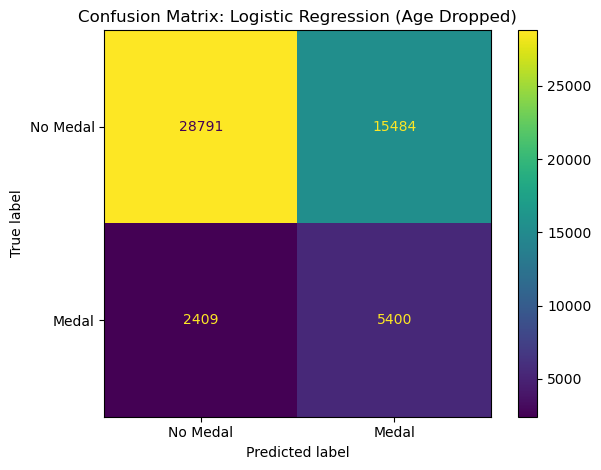

array([[28791, 15484],
       [ 2409,  5400]])

In [46]:
if best_model_name == "Logistic Regression (Age Dropped)":
    best_y_test = y_test_age
    best_y_pred = age_drop_pred
    best_y_prob = age_drop_prob
    best_pipeline = fitted_age_drop
    best_X_test = X_test_age
else:
    best_y_test = y_test
    best_y_pred = {
        "Logistic Regression (Age Imputed)": log_pred,
        "Decision Tree": tree_pred,
        "Random Forest": rf_pred
    }[best_model_name]
    best_y_prob = {
        "Logistic Regression (Age Imputed)": log_prob,
        "Decision Tree": tree_prob,
        "Random Forest": rf_prob
    }[best_model_name]
    best_pipeline = {
        "Logistic Regression (Age Imputed)": fitted_log_reg,
        "Decision Tree": fitted_tree,
        "Random Forest": fitted_rf
    }[best_model_name]
    best_X_test = X_test

cm = confusion_matrix(best_y_test, best_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Medal", "Medal"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.show()

cm

**Business interpretation:**  
False negatives mean actual medal winners that the model missed.  
False positives mean athletes predicted to win medals who did not.

For this project, false negatives are more costly because missing a strong medal candidate could reduce the effectiveness of training and resource allocation.


## 6.15 Classification Report for Best Model

In [47]:
print(classification_report(best_y_test, best_y_pred, target_names=["No Medal", "Medal"]))

              precision    recall  f1-score   support

    No Medal       0.92      0.65      0.76     44275
       Medal       0.26      0.69      0.38      7809

    accuracy                           0.66     52084
   macro avg       0.59      0.67      0.57     52084
weighted avg       0.82      0.66      0.70     52084



## 6.16 ROC Curve and Precision-Recall Curve

ROC and Precision-Recall curves help evaluate classification performance beyond one threshold.  
For imbalanced data, the Precision-Recall curve is especially useful.


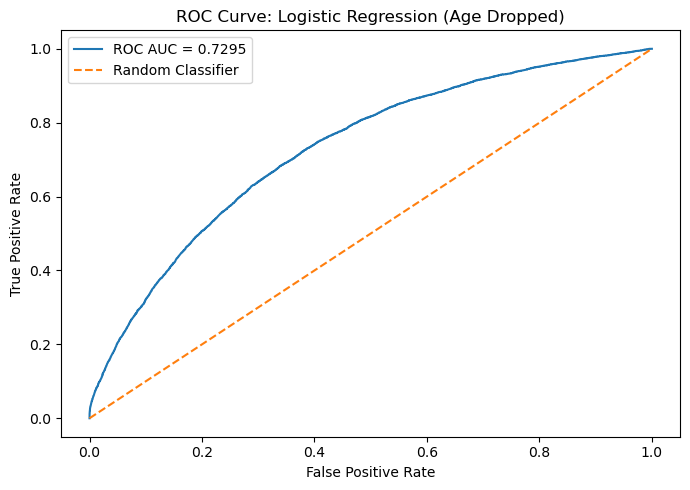

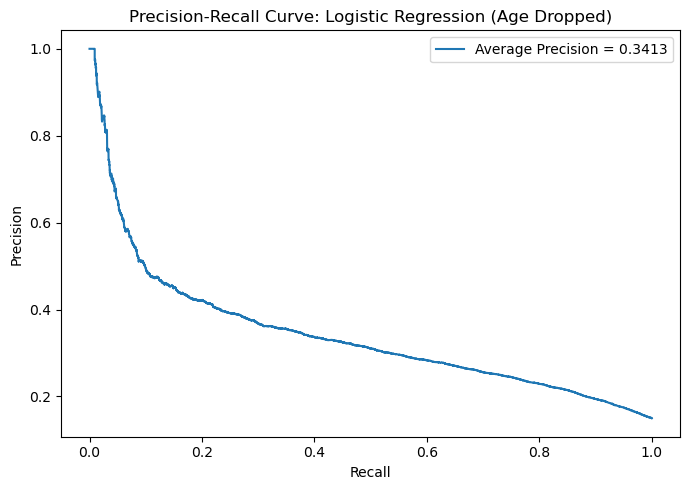

In [48]:
fpr, tpr, roc_thresholds = roc_curve(best_y_test, best_y_prob)
roc_auc = roc_auc_score(best_y_test, best_y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title(f"ROC Curve: {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(best_y_test, best_y_prob)
avg_precision = average_precision_score(best_y_test, best_y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, label=f"Average Precision = {avg_precision:.4f}")
plt.title(f"Precision-Recall Curve: {best_model_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

## 6.17 Threshold Discussion

The default classification threshold is 0.50.  
However, in imbalanced classification, changing the threshold can change precision and recall.

Lowering the threshold usually increases recall but may create more false positives.  
Raising the threshold usually increases precision but may miss more medal winners.


In [49]:
thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds_to_test:
    y_pred_threshold = (best_y_prob >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(best_y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(best_y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(best_y_test, y_pred_threshold, zero_division=0)
    })

threshold_table = pd.DataFrame(threshold_results)
threshold_table[["Precision", "Recall", "F1"]] = threshold_table[["Precision", "Recall", "F1"]].round(4)

threshold_table

,Threshold,Precision,Recall,F1
0,0.3,0.1943,0.8991,0.3195
1,0.4,0.2265,0.8097,0.3540
2,0.5,0.2586,0.6915,0.3764
3,0.6,0.2981,0.5407,0.3843
4,0.7,0.3787,0.2813,0.3229


## 6.18 Error Analysis

This section identifies where the model fails.

We create a table of false positives and false negatives.  
This supports the required “failure modes” paragraph in the report.


In [50]:
error_analysis = best_X_test.copy()
error_analysis["Actual"] = best_y_test.values
error_analysis["Predicted"] = best_y_pred
error_analysis["Predicted_Probability"] = best_y_prob

false_positives = error_analysis[
    (error_analysis["Actual"] == 0) & (error_analysis["Predicted"] == 1)
].copy()

false_negatives = error_analysis[
    (error_analysis["Actual"] == 1) & (error_analysis["Predicted"] == 0)
].copy()

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

display(false_positives.head())
display(false_negatives.head())

False positives: 15484
False negatives: 2409


,Sex,Height,Weight,BMI,Year,Season,Sport,Event,Actual,Predicted,Predicted_Probability
190146,F,190.0,89.0,24.653740,2016,Summer,Basketball,Basketball Women's Basketball,0,1,0.759476
191279,M,181.0,86.0,26.250725,1972,Summer,Cycling,"Cycling Men's Team Pursuit, 4,000 metres",0,1,0.674109
260836,F,169.0,63.0,22.058051,2012,Summer,Judo,Judo Women's Half-Middleweight,0,1,0.512624
125171,M,192.0,93.0,25.227865,1988,Summer,Water Polo,Water Polo Men's Water Polo,0,1,0.691913
179150,M,193.0,100.0,26.846358,1998,Winter,Ice Hockey,Ice Hockey Men's Ice Hockey,0,1,0.721104


,Sex,Height,Weight,BMI,Year,Season,Sport,Event,Actual,Predicted,Predicted_Probability
104561,M,180.0,72.0,22.222222,1972,Summer,Swimming,Swimming Men's 200 metres Backstroke,1,0,0.359722
61479,M,182.0,73.0,22.038401,2000,Summer,Athletics,Athletics Men's Triple Jump,1,0,0.302673
255246,F,166.0,56.0,20.322253,1988,Summer,Athletics,Athletics Women's 800 metres,1,0,0.320026
114217,M,168.0,62.0,21.967120,2004,Summer,Gymnastics,Gymnastics Men's Pommelled Horse,1,0,0.112883
143851,M,160.0,55.0,21.484375,1976,Summer,Rowing,Rowing Men's Coxed Fours,1,0,0.476397


## 6.19 Failure Modes Summary

Use this in the final report:

The model struggles most with borderline athlete-event records where medal and non-medal profiles overlap.  
False positives occur when the model identifies athletes as likely medal winners, but they do not win.  
False negatives occur when actual medal winners are missed.

From a business perspective, false negatives are more serious because they may cause decision-makers to overlook high-potential athletes.  
False positives are also important because they may lead to extra resources being assigned to athletes who do not eventually win medals.


## 6.20 Final Modeling Summary

Use this in the final report:

- Logistic Regression was used as the baseline because it is simple and interpretable.
- Random Forest was used as a stronger model because it can capture complex nonlinear patterns.
- F1-score was used as the main metric because medal winners are the minority class.
- Age was tested carefully because missing Age records had different medal rates.
- The final selected model is the model with the best F1-score and best balance between precision and recall.


# 7. Limitations

This section documents the key limitations of the current analysis and model. These are important to acknowledge because they affect how much we can trust the predictions and how the model should be used in practice.

## 7.1 Class Imbalance

Only about 14.75% of the cleaned records are medal outcomes. The other 85% are non-medal records. This is a big deal because it means the model sees far more "no medal" examples than "medal" examples during training. Even with `class_weight="balanced"` turned on, the best F1-score for the medal class stays below 0.40. The model catches a decent number of medal winners (recall around 0.69) but also flags a lot of non-winners as potential medalists (precision around 0.26). The imbalance is baked into the nature of the Olympics. Most athletes who compete do not win medals. That is just how it works. But it makes building an accurate classifier much harder because the positive class is genuinely rare.

## 7.2 Moderate Predictive Performance

The best model (Logistic Regression with Age dropped) achieved an F1-score of about 0.38. That is better than random guessing but still not strong enough for high-stakes decisions. The model is useful as an early screening tool to flag athlete profiles that look like they could medal. But it should not be treated as a definitive prediction. There are too many false positives for that. In practice, the model should support human judgment rather than replace it. An analyst could use the model output as one input alongside other context that is not in the dataset.

## 7.3 Feature Limitations

The predictors in this dataset are mostly demographic and physical: age, height, weight, BMI, sex, sport, event, season, year. These capture some signal but they miss a lot of context that matters for medal prediction. Things like:

- Training quality and coaching staff  
- National sports funding and investment  
- Athlete injury history  
- Prior competition performance (world rankings, qualifying times)  
- Mental preparation and experience level  

None of that is in the dataset. The model is working with a limited picture of what actually determines medal outcomes. Adding even one strong contextual feature (like prior world ranking) could make a real difference in model performance.

## 7.4 Missing Values

Age, Height, Weight, BMI all have missing values. The missingness in Age is not random. Records with missing Age have a different medal rate than records where Age is present (Section 6.3 showed this). That means imputing Age with the median could introduce bias because the imputed values would not reflect the true pattern in those records.

This is why the Age-dropped version of Logistic Regression was tested separately. The analysis showed that dropping Age rows and imputing Age gave similar F1-scores, which suggests Age was not a dominant predictor on its own. But the broader point stands: missing values in key physical variables reduce the reliability of the model, especially for earlier Olympic years where data collection was less consistent.

## 7.5 High Cardinality in Event

The Event column has hundreds of unique values. When one-hot encoded, this creates a very wide feature matrix. Each event becomes its own binary column, and most of those columns are zeros for any given row. This sparsity can make models less stable. Small changes in the training data can shift which event dummies get weight.

High cardinality also means some events have very few records. The model might not have enough examples from a niche event to learn anything meaningful about medal patterns in that event. One potential fix would be to group rare events into an "Other" category or to use target encoding instead of one-hot encoding. But neither approach was applied here.

## 7.6 Historical Scope

The dataset covers Olympic Games from 1896 through 2016. That is 120 years of data. The problem is that the Olympics have changed a lot over that time. New sports have been added. Countries have split or merged. Training methods and nutrition science have evolved dramatically. Medal competitiveness in 1920 was very different from medal competitiveness in 2016.

The model treats all of these time periods equally. A record from 1900 and a record from 2012 both contribute the same way to training. But patterns from early Olympics might not be relevant to modern competition. If the goal is to predict future medal outcomes, the historical data might actually introduce noise rather than signal. Filtering to recent decades could help but would also reduce the training set size.

## 7.7 Potential Bias

Some countries and sports are heavily overrepresented in the dataset. Countries like the USA and Russia have far more athlete-event records than smaller nations. Sports with many events (like Athletics or Swimming) contribute more rows than sports with only a few events (like Handball). This means the model is trained primarily on patterns from dominant countries and popular sports.

Predictions for underrepresented countries or less common sports might be unreliable because the model has not seen enough examples from those groups. The dataset reflects the historical structure of the Olympics, which is not evenly distributed across nations or sports.

## 7.8 No Temporal Validation

The train/test split was done randomly with stratification. This means training and test records can come from the same Olympic year. In a real prediction scenario, we would be predicting future Olympics based on past data. A time-based split (for example, training on pre-2012 data and testing on 2012-2016 data) would be a more realistic evaluation setup. The current random split might overestimate model performance because the model can learn year-specific patterns that would not be available at prediction time.

## 7.9 Summary

The project has a solid baseline workflow. The data was cleaned and validated in a leakage-safe way. But predictive power is constrained by class imbalance, limited features, missing values, high cardinality, and the historical scope of the data. The model works best as an early screening tool to flag high-potential athlete profiles for further review. It is not accurate enough for standalone decision-making.

For a production-level system, the next steps would be adding richer contextual features and applying better class imbalance techniques like SMOTE or threshold tuning. A time-based validation split would give more realistic performance estimates. Focusing on recent Olympic years would also help since the data from those years is more consistent and relevant to future predictions.